In [1]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, accuracy_score
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SequentialFeatureSelector

In [2]:
consDF = pd.read_parquet("/uss/hdsi-prismdata/q2-ucsd-consDF.pqt")
consDF = consDF.drop(columns = ["credit_score"])
consDF = consDF.dropna()
acctDF = pd.read_parquet("/uss/hdsi-prismdata/q2-ucsd-acctDF.pqt")
trxnDF = pd.read_parquet("/uss/hdsi-prismdata/q2-ucsd-trxnDF.pqt")
catmap = pd.read_csv("/uss/hdsi-prismdata/q2-ucsd-cat-map.csv")
acctDF = acctDF[acctDF["prism_consumer_id"].isin(consDF['prism_consumer_id'])]
acctDF["balance_date"] = pd.to_datetime(acctDF["balance_date"])
trxnDF = trxnDF[trxnDF["prism_consumer_id"].isin(consDF['prism_consumer_id'])]
trxnDF = trxnDF.drop_duplicates()
trxnDF["posted_date"] = pd.to_datetime(trxnDF["posted_date"])
trxnDF['posted_date'] = pd.to_datetime(trxnDF['posted_date'])
consDF['evaluation_date'] = pd.to_datetime(consDF['evaluation_date'])

# Merge evaluation_date into transaction DF
trxnDF = trxnDF.merge(
    consDF[['prism_consumer_id', 'evaluation_date']],
    on='prism_consumer_id',
    how='left'
)
acctDF = acctDF.merge(
    consDF[['prism_consumer_id', 'evaluation_date']],
    on='prism_consumer_id',
    how='left'
)
# Keep only transactions before or on evaluation_date
trxnDF = trxnDF[trxnDF['posted_date'] <= trxnDF['evaluation_date']].copy()
acctDF = acctDF[acctDF['balance_date'] <= acctDF['evaluation_date']].copy()
all_feats = pd.read_parquet("all_feats.parquet")
all_feats_shrink = pd.read_parquet("all_feats_shrink.parquet")

In [44]:
def prepare_dates(acctDF: pd.DataFrame, trxnDF: pd.DataFrame):
    """Cast all date columns to datetime."""
    for col in ["balance_date", "evaluation_date"]:
        acctDF[col] = pd.to_datetime(acctDF[col])

    for col in ["posted_date", "evaluation_date"]:
        trxnDF[col] = pd.to_datetime(trxnDF[col])

    return acctDF, trxnDF


# ──────────────────────────────────────────────────────────────────────────────
# 1.  ACCOUNT FEATURES  (from acctDF)
# ──────────────────────────────────────────────────────────────────────────────

def build_account_features(acctDF: pd.DataFrame) -> pd.DataFrame:
    """
    Aggregate account-level data to one row per consumer.

    Features created
    ─────────────────
    acct_total_balance          : sum of all balances
    acct_savings_balance        : sum of SAVINGS balances
    acct_checking_balance       : sum of CHECKING balances
    acct_num_accounts           : number of accounts
    acct_num_savings            : number of SAVINGS accounts
    acct_num_checking           : number of CHECKING accounts
    acct_savings_ratio          : savings / total balance
    acct_min_balance            : minimum balance across accounts
    acct_max_balance            : maximum balance
    acct_balance_std            : balance volatility across accounts
    acct_has_savings            : binary flag
    acct_has_checking           : binary flag
    acct_negative_balance_flag  : 1 if any account has balance < 0
    """
    grp = acctDF.groupby("prism_consumer_id")

    feat = pd.DataFrame(index=acctDF["prism_consumer_id"].unique())
    feat.index.name = "prism_consumer_id"

    feat["acct_total_balance"]    = grp["balance"].sum()
    feat["acct_savings_balance"]  = (
        acctDF[acctDF["account_type"] == "SAVINGS"]
        .groupby("prism_consumer_id")["balance"].sum()
    )
    feat["acct_checking_balance"] = (
        acctDF[acctDF["account_type"] == "CHECKING"]
        .groupby("prism_consumer_id")["balance"].sum()
    )
    feat["acct_num_accounts"]  = grp["prism_account_id"].nunique()
    feat["acct_num_savings"]   = (
        acctDF[acctDF["account_type"] == "SAVINGS"]
        .groupby("prism_consumer_id")["prism_account_id"].nunique()
    )
    feat["acct_num_checking"]  = (
        acctDF[acctDF["account_type"] == "CHECKING"]
        .groupby("prism_consumer_id")["prism_account_id"].nunique()
    )
    feat["acct_min_balance"]   = grp["balance"].min()
    feat["acct_max_balance"]   = grp["balance"].max()
    feat["acct_balance_std"]   = grp["balance"].std().fillna(0)

    # Fill NaN balances (consumer has no account of that type) with 0
    feat[["acct_savings_balance", "acct_checking_balance",
          "acct_num_savings",    "acct_num_checking"]] = (
        feat[["acct_savings_balance", "acct_checking_balance",
              "acct_num_savings",    "acct_num_checking"]].fillna(0)
    )

    # Ratios
    feat["acct_savings_ratio"] = (
        feat["acct_savings_balance"] /
        feat["acct_total_balance"].replace(0, np.nan)
    ).fillna(0)

    # Binary flags
    feat["acct_has_savings"]  = (feat["acct_num_savings"]  > 0).astype(int)
    feat["acct_has_checking"] = (feat["acct_num_checking"] > 0).astype(int)
    feat["acct_negative_balance_flag"] = (
        grp["balance"].min() < 0
    ).astype(int)

    return feat.reset_index()


# ──────────────────────────────────────────────────────────────────────────────
# 2.  TRANSACTION FEATURES  (from trxnDF)
# ──────────────────────────────────────────────────────────────────────────────

def _trxn_window(trxnDF: pd.DataFrame, days: int) -> pd.DataFrame:
    """Return transactions within `days` before each consumer's evaluation_date."""
    df = trxnDF.copy()
    df["days_before_eval"] = (df["evaluation_date"] - df["posted_date"]).dt.days
    return df[(df["days_before_eval"] >= 0) & (df["days_before_eval"] <= days)]


def build_transaction_features(trxnDF: pd.DataFrame) -> pd.DataFrame:
    """
    Aggregate transaction data to one row per consumer.

    Windows used : 30, 60, 90 days before evaluation_date

    Features created (per window, e.g. _30d / _60d / _90d)
    ────────────────────────────────────────────────────────
    trxn_total_credits_{w}d         : sum of CREDIT amounts
    trxn_total_debits_{w}d          : sum of DEBIT amounts
    trxn_net_cashflow_{w}d          : credits - debits
    trxn_num_credits_{w}d           : count of CREDIT transactions
    trxn_num_debits_{w}d            : count of DEBIT transactions
    trxn_avg_credit_{w}d            : mean CREDIT amount
    trxn_avg_debit_{w}d             : mean DEBIT amount
    trxn_credit_debit_ratio_{w}d    : total credits / total debits
    trxn_std_credit_{w}d            : volatility of credit amounts
    trxn_std_debit_{w}d             : volatility of debit amounts

    Window-independent features
    ────────────────────────────
    trxn_days_since_last_credit     : recency of income
    trxn_days_since_last_debit      : recency of spending
    trxn_num_categories             : breadth of spending
    trxn_recurring_credit_flag      : proxy for regular payroll
    """
    all_consumers = trxnDF["prism_consumer_id"].unique()
    feat = pd.DataFrame({"prism_consumer_id": all_consumers}).set_index("prism_consumer_id")

    for days in [90, 180, 365]:
        w = _trxn_window(trxnDF, days)
        sfx = f"_{days}d"

        credits = w[w["credit_or_debit"] == "CREDIT"]
        debits  = w[w["credit_or_debit"] == "DEBIT"]

        feat[f"trxn_total_credits{sfx}"]  = credits.groupby("prism_consumer_id")["amount"].sum()
        feat[f"trxn_total_debits{sfx}"]   = debits.groupby("prism_consumer_id")["amount"].sum()
        feat[f"trxn_num_credits{sfx}"]    = credits.groupby("prism_consumer_id")["amount"].count()
        feat[f"trxn_num_debits{sfx}"]     = debits.groupby("prism_consumer_id")["amount"].count()
        feat[f"trxn_avg_credit{sfx}"]     = credits.groupby("prism_consumer_id")["amount"].mean()
        feat[f"trxn_avg_debit{sfx}"]      = debits.groupby("prism_consumer_id")["amount"].mean()
        feat[f"trxn_std_credit{sfx}"]     = credits.groupby("prism_consumer_id")["amount"].std()
        feat[f"trxn_std_debit{sfx}"]      = debits.groupby("prism_consumer_id")["amount"].std()

        feat[f"trxn_net_cashflow{sfx}"] = (
            feat[f"trxn_total_credits{sfx}"].fillna(0) -
            feat[f"trxn_total_debits{sfx}"].fillna(0)
        )
        feat[f"trxn_credit_debit_ratio{sfx}"] = (
            feat[f"trxn_total_credits{sfx}"] /
            feat[f"trxn_total_debits{sfx}"].replace(0, np.nan)
        )

    # Fill NaN (no transactions in window) with 0
    feat = feat.fillna(0)

    # ── Window-independent features ──────────────────────────────────────────
    eval_date = trxnDF.groupby("prism_consumer_id")["evaluation_date"].first()

    last_credit = (
        trxnDF[trxnDF["credit_or_debit"] == "CREDIT"]
        .groupby("prism_consumer_id")["posted_date"].max()
    )
    last_debit = (
        trxnDF[trxnDF["credit_or_debit"] == "DEBIT"]
        .groupby("prism_consumer_id")["posted_date"].max()
    )

    feat["trxn_days_since_last_credit"] = (eval_date - last_credit).dt.days
    feat["trxn_days_since_last_debit"]  = (eval_date - last_debit).dt.days

    feat["trxn_num_categories"] = (
        trxnDF.groupby("prism_consumer_id")["category"].nunique()
    )

    # Recurring credit flag: consumer has 2+ credits with the same amount
    # (simple payroll / recurring income proxy)
    recurring = (
        trxnDF[trxnDF["credit_or_debit"] == "CREDIT"]
        .groupby(["prism_consumer_id", "amount"])
        .size()
        .reset_index(name="cnt")
    )
    has_recurring = (
        recurring[recurring["cnt"] >= 2]
        .groupby("prism_consumer_id")
        .size()
        .gt(0)
        .astype(int)
    )
    feat["trxn_recurring_credit_flag"] = has_recurring

    feat = feat.fillna(0)
    return feat.reset_index()


# ── ────────────────────────────────────────────────────────────────────────────
# 3.  COMBINE ALL FEATURES
# ── ────────────────────────────────────────────────────────────────────────────

def build_features(acctDF: pd.DataFrame, trxnDF: pd.DataFrame) -> pd.DataFrame:
    """
    Master function — returns a single consumer-level feature DataFrame.

    Usage
    ─────
        acctDF, trxnDF = prepare_dates(acctDF, trxnDF)
        features_df    = build_features(acctDF, trxnDF)

    Then merge with your target labels:
        df = features_df.merge(labels_df, on="prism_consumer_id", how="inner")
    """
    acctDF, trxnDF = prepare_dates(acctDF, trxnDF)

    acct_feat = build_account_features(acctDF)
    trxn_feat = build_transaction_features(trxnDF)

    features_df = acct_feat.merge(trxn_feat, on="prism_consumer_id", how="outer")
    features_df = features_df.fillna(0)

    print(f"✅ Feature matrix shape: {features_df.shape}")
    print(f"   Consumers : {features_df['prism_consumer_id'].nunique()}")
    print(f"   Features  : {features_df.shape[1] - 1}")

    return features_df

In [47]:
def build_balance_trend_features(acctDF: pd.DataFrame) -> pd.DataFrame:
    """
    Uses multiple balance snapshots over time per consumer to capture trend.

    Features
    ─────────
    bal_trend_slope          : linear regression slope of balance over time
    bal_trend_direction      : 1 = improving, -1 = declining, 0 = flat
    bal_pct_change_latest    : % change from earliest to latest snapshot
    bal_num_snapshots        : how many balance observations we have
    bal_days_span            : days between first and last snapshot
    """
    df = acctDF.copy()
    df = df.sort_values(["prism_consumer_id", "balance_date"])

    records = []
    for cid, grp in df.groupby("prism_consumer_id"):
        grp = grp.sort_values("balance_date")
        total_by_date = grp.groupby("balance_date")["balance"].sum().reset_index()
        total_by_date.columns = ["balance_date", "total_balance"]

        n = len(total_by_date)
        if n < 2:
            slope, pct_change = 0.0, 0.0
        else:
            x = (total_by_date["balance_date"] - total_by_date["balance_date"].min()).dt.days.values
            y = total_by_date["total_balance"].values
            slope = float(np.polyfit(x, y, 1)[0]) if x.std() > 0 else 0.0
            first, last = y[0], y[-1]
            pct_change = (last - first) / abs(first) if first != 0 else 0.0

        days_span = (
            (total_by_date["balance_date"].max() - total_by_date["balance_date"].min()).days
        )

        records.append({
            "prism_consumer_id": cid,
            "bal_trend_slope": slope,
            "bal_trend_direction": int(np.sign(slope)),
            "bal_pct_change_latest": pct_change,
            "bal_num_snapshots": n,
            "bal_days_span": days_span,
        })

    return pd.DataFrame(records)


# ──────────────────────────────────────────────────────────────────────────────
# 6.  OVERDRAFT / FINANCIAL STRESS SIGNALS
# ──────────────────────────────────────────────────────────────────────────────

def build_stress_features(trxnDF: pd.DataFrame, acctDF: pd.DataFrame) -> pd.DataFrame:
    """
    Features capturing signs of financial stress.

    Features
    ─────────
    stress_low_balance_flag          : checking balance < 100 at eval
    stress_near_zero_balance_flag    : checking balance < 10
    stress_debit_exceeds_credit_30d  : spent more than earned in last 30 days
    stress_debit_exceeds_credit_90d  : same for 90 days
    stress_large_debit_count_30d     : # debits > 500 in last 30 days
    stress_max_single_debit_30d      : largest single debit in 30 days
    stress_cashflow_negative_months  : # trailing months with negative net flow
    """
    records = []

    # Checking balance at evaluation date
    checking = acctDF[acctDF["account_type"] == "CHECKING"]
    check_bal = checking.groupby("prism_consumer_id")["balance"].sum()

    trxnDF = trxnDF.copy()
    trxnDF["days_before_eval"] = (trxnDF["evaluation_date"] - trxnDF["posted_date"]).dt.days

    w90  = trxnDF[(trxnDF["days_before_eval"] >= 0) & (trxnDF["days_before_eval"] <= 90)]
    w180 = trxnDF[(trxnDF["days_before_eval"] >= 0) & (trxnDF["days_before_eval"] <= 180)]

    credits_90  = w90[w90["credit_or_debit"] == "CREDIT"].groupby("prism_consumer_id")["amount"].sum()
    debits_90   = w90[w90["credit_or_debit"] == "DEBIT"].groupby("prism_consumer_id")["amount"].sum()
    credits_180 = w180[w180["credit_or_debit"] == "CREDIT"].groupby("prism_consumer_id")["amount"].sum()
    debits_180  = w180[w180["credit_or_debit"] == "DEBIT"].groupby("prism_consumer_id")["amount"].sum()

    large_debits_90 = (
        w90[(w90["credit_or_debit"] == "DEBIT") & (w90["amount"] > 500)]
        .groupby("prism_consumer_id")["amount"].count()
    )
    max_debit_90 = (
        w90[w90["credit_or_debit"] == "DEBIT"]
        .groupby("prism_consumer_id")["amount"].max()
    )

    # Monthly net cash flow — count negative months in trailing 180 days
    trxnDF["month"] = trxnDF["posted_date"].dt.to_period("M")
    monthly = trxnDF.copy()
    monthly["signed"] = monthly.apply(
        lambda r: r["amount"] if r["credit_or_debit"] == "CREDIT" else -r["amount"], axis=1
    )
    monthly_net = (
        monthly[monthly["days_before_eval"] <= 180]
        .groupby(["prism_consumer_id", "month"])["signed"].sum()
        .reset_index()
    )
    neg_months = (
        monthly_net[monthly_net["signed"] < 0]
        .groupby("prism_consumer_id")["month"].count()
    )

    all_consumers = trxnDF["prism_consumer_id"].unique()
    feat = pd.DataFrame({"prism_consumer_id": all_consumers}).set_index("prism_consumer_id")

    feat["stress_low_balance_flag"]       = (check_bal < 100).astype(int)
    feat["stress_near_zero_balance_flag"] = (check_bal < 10).astype(int)
    all_idx = feat.index
    debits_90_   = debits_90.reindex(all_idx, fill_value=0)
    credits_90_  = credits_90.reindex(all_idx, fill_value=0)
    debits_180_  = debits_180.reindex(all_idx, fill_value=0)
    credits_180_ = credits_180.reindex(all_idx, fill_value=0)

    feat["stress_debit_exceeds_credit_90d"]  = (debits_90_  > credits_90_).astype(int)
    feat["stress_debit_exceeds_credit_180d"] = (debits_180_ > credits_180_).astype(int)
    feat["stress_large_debit_count_90d"]  = large_debits_90
    feat["stress_max_single_debit_90d"]   = max_debit_90
    feat["stress_cashflow_negative_months"] = neg_months

    return feat.fillna(0).reset_index()


# ──────────────────────────────────────────────────────────────────────────────
# 7.  INCOME STABILITY & REGULARITY
# ──────────────────────────────────────────────────────────────────────────────

def build_income_features(trxnDF: pd.DataFrame) -> pd.DataFrame:
    """
    Captures income regularity — a strong predictor of creditworthiness.

    Features
    ─────────
    inc_monthly_mean             : average monthly credit inflow
    inc_monthly_std              : volatility of monthly income
    inc_coefficient_of_variation : std / mean (stability ratio; lower = more stable)
    inc_num_months_with_income   : months that had any credit
    inc_min_monthly_income       : worst income month (downside risk)
    inc_max_monthly_income       : best income month
    inc_income_consistency_score : % of months with income >= 50% of mean
    """
    df = trxnDF.copy()
    df["days_before_eval"] = (df["evaluation_date"] - df["posted_date"]).dt.days
    df = df[(df["days_before_eval"] >= 0) & (df["days_before_eval"] <= 365)]
    df["month"] = df["posted_date"].dt.to_period("M")

    credits = df[df["credit_or_debit"] == "CREDIT"]
    monthly_income = (
        credits.groupby(["prism_consumer_id", "month"])["amount"]
        .sum()
        .reset_index()
    )

    grp = monthly_income.groupby("prism_consumer_id")["amount"]

    feat = pd.DataFrame()
    feat["inc_monthly_mean"]           = grp.mean()
    feat["inc_monthly_std"]            = grp.std().fillna(0)
    feat["inc_num_months_with_income"] = grp.count()
    feat["inc_min_monthly_income"]     = grp.min()
    feat["inc_max_monthly_income"]     = grp.max()
    feat["inc_coefficient_of_variation"] = (
        feat["inc_monthly_std"] / feat["inc_monthly_mean"].replace(0, np.nan)
    ).fillna(0)

    # Consistency: % months where income >= 50% of that consumer's mean
    def consistency(group):
        mean = group["amount"].mean()
        return (group["amount"] >= 0.5 * mean).mean()

    feat["inc_income_consistency_score"] = (
        monthly_income.groupby("prism_consumer_id").apply(consistency)
    )

    return feat.fillna(0).reset_index()


# ──────────────────────────────────────────────────────────────────────────────
# 8.  SPENDING BEHAVIOUR & RATIOS
# ──────────────────────────────────────────────────────────────────────────────

def build_spending_features(trxnDF: pd.DataFrame) -> pd.DataFrame:
    """
    Captures spending patterns and category concentration.

    Features
    ─────────
    spend_top_category               : most frequent spending category (encoded)
    spend_category_concentration     : Herfindahl index of category spend (higher = concentrated)
    spend_expense_to_income_ratio_30d: debits / credits in 30 days (>1 = overspending)
    spend_expense_to_income_ratio_90d: same for 90 days
    spend_avg_transaction_gap_days   : mean days between any transactions (activity regularity)
    spend_weekend_debit_ratio        : proportion of debits on weekends
    spend_num_small_debits_30d       : # debits < 20 (small purchases / fees)
    spend_num_round_debits_30d       : # debits that are round numbers (subscription proxy)
    """
    df = trxnDF.copy()
    df["days_before_eval"] = (df["evaluation_date"] - df["posted_date"]).dt.days
    w90  = df[(df["days_before_eval"] >= 0) & (df["days_before_eval"] <= 90)]
    w180 = df[(df["days_before_eval"] >= 0) & (df["days_before_eval"] <= 180)]

    debits_90   = w90[w90["credit_or_debit"] == "DEBIT"]
    credits_90  = w90[w90["credit_or_debit"] == "CREDIT"]
    debits_180  = w180[w180["credit_or_debit"] == "DEBIT"]
    credits_180 = w180[w180["credit_or_debit"] == "CREDIT"]

    # Category concentration (Herfindahl index)
    cat_spend = (
        df[df["credit_or_debit"] == "DEBIT"]
        .groupby(["prism_consumer_id", "category"])["amount"].sum()
        .reset_index()
    )
    cat_total = cat_spend.groupby("prism_consumer_id")["amount"].sum().rename("total")
    cat_spend = cat_spend.merge(cat_total, on="prism_consumer_id")
    cat_spend["share"] = cat_spend["amount"] / cat_spend["total"]
    hhi = (
        (cat_spend["share"] ** 2)
        .groupby(cat_spend["prism_consumer_id"]).sum()
    )

    # Transaction gap (days between consecutive transactions)
    df_sorted = df.sort_values(["prism_consumer_id", "posted_date"])
    df_sorted["prev_date"] = df_sorted.groupby("prism_consumer_id")["posted_date"].shift(1)
    df_sorted["gap_days"] = (df_sorted["posted_date"] - df_sorted["prev_date"]).dt.days
    avg_gap = df_sorted.groupby("prism_consumer_id")["gap_days"].mean()

    # Weekend debits
    debits_all = df[df["credit_or_debit"] == "DEBIT"].copy()
    debits_all["is_weekend"] = debits_all["posted_date"].dt.dayofweek >= 5
    weekend_ratio = debits_all.groupby("prism_consumer_id")["is_weekend"].mean()

    # Small debits (< $20) — use 90d window
    small_debits = (
        debits_90[debits_90["amount"] < 20]
        .groupby("prism_consumer_id")["amount"].count()
    )

    # Round number debits (subscription proxy) — use 90d window
    debits_90_copy = debits_90.copy()
    debits_90_copy["is_round"] = (debits_90_copy["amount"] % 1 == 0)
    round_debits = debits_90_copy.groupby("prism_consumer_id")["is_round"].sum()

    all_consumers = df["prism_consumer_id"].unique()
    feat = pd.DataFrame({"prism_consumer_id": all_consumers}).set_index("prism_consumer_id")

    feat["spend_category_concentration"]       = hhi
    feat["spend_expense_to_income_ratio_90d"]  = (
        debits_90.groupby("prism_consumer_id")["amount"].sum() /
        credits_90.groupby("prism_consumer_id")["amount"].sum().replace(0, np.nan)
    )
    feat["spend_expense_to_income_ratio_180d"] = (
        debits_180.groupby("prism_consumer_id")["amount"].sum() /
        credits_180.groupby("prism_consumer_id")["amount"].sum().replace(0, np.nan)
    )
    feat["spend_avg_transaction_gap_days"] = avg_gap
    feat["spend_weekend_debit_ratio"]      = weekend_ratio
    feat["spend_num_small_debits_90d"]     = (
        debits_90[debits_90["amount"] < 20]
        .groupby("prism_consumer_id")["amount"].count()
    )
    debits_90_copy = debits_90.copy()
    debits_90_copy["is_round"] = (debits_90_copy["amount"] % 1 == 0)
    feat["spend_num_round_debits_90d"] = debits_90_copy.groupby("prism_consumer_id")["is_round"].sum()

    return feat.fillna(0).reset_index()


# ──────────────────────────────────────────────────────────────────────────────
# 9.  VELOCITY CHANGES (recent vs. historical)
# ──────────────────────────────────────────────────────────────────────────────

def build_velocity_features(trxnDF: pd.DataFrame) -> pd.DataFrame:
    """
    Detects sudden changes in financial behaviour — a key risk signal.

    Features
    ─────────
    vel_credit_change_30v90      : (credits_30d / 30) / (credits_90d / 90) — acceleration
    vel_debit_change_90v365       : same for debits
    vel_cashflow_change_90v365    : net cash flow rate change
    vel_txn_freq_change_90v365    : transaction frequency change
    vel_avg_debit_change_90v365   : average debit size change (spending up?)
    """
    df = trxnDF.copy()
    df["days_before_eval"] = (df["evaluation_date"] - df["posted_date"]).dt.days

    def window_agg(days):
        w = df[(df["days_before_eval"] >= 0) & (df["days_before_eval"] <= days)]
        cr = w[w["credit_or_debit"] == "CREDIT"].groupby("prism_consumer_id")["amount"]
        db = w[w["credit_or_debit"] == "DEBIT"].groupby("prism_consumer_id")["amount"]
        return {
            "credits": cr.sum() / days,
            "debits":  db.sum() / days,
            "net":    (cr.sum().fillna(0) - db.sum().fillna(0)) / days,
            "freq":    w.groupby("prism_consumer_id")["amount"].count() / days,
            "avg_debit": db.mean(),
        }

    r90  = window_agg(90)
    r365 = window_agg(365)

    all_consumers = df["prism_consumer_id"].unique()
    feat = pd.DataFrame({"prism_consumer_id": all_consumers}).set_index("prism_consumer_id")

    def safe_ratio(num, den):
        return (num / den.replace(0, np.nan)).fillna(1.0)

    feat["vel_credit_change_90v365"]   = safe_ratio(r90["credits"],   r365["credits"])
    feat["vel_debit_change_90v365"]    = safe_ratio(r90["debits"],    r365["debits"])
    feat["vel_cashflow_change_90v365"] = safe_ratio(r90["net"],       r365["net"].abs())
    feat["vel_txn_freq_change_90v365"] = safe_ratio(r90["freq"],      r365["freq"])
    feat["vel_avg_debit_change_90v365"]= safe_ratio(r90["avg_debit"], r365["avg_debit"])

    return feat.fillna(1.0).reset_index()


# ──────────────────────────────────────────────────────────────────────────────
# 10. CALENDAR / TIMING PATTERNS
# ──────────────────────────────────────────────────────────────────────────────

def build_calendar_features(trxnDF: pd.DataFrame) -> pd.DataFrame:
    """
    Day-of-month and timing signals — e.g. credits at month start suggest payroll.

    Features
    ─────────
    cal_pct_credits_start_of_month   : % credits in days 1–5 (payroll signal)
    cal_pct_credits_end_of_month     : % credits in days 26–31
    cal_pct_debits_end_of_month      : bills often due at month end
    cal_days_between_credits_mean    : average gap between credit transactions
    cal_days_between_credits_std     : consistency of income timing
    """
    df = trxnDF.copy()
    df["day_of_month"] = df["posted_date"].dt.day

    credits = df[df["credit_or_debit"] == "CREDIT"].copy()
    debits  = df[df["credit_or_debit"] == "DEBIT"].copy()

    credits_start = credits[credits["day_of_month"] <= 5]
    credits_end   = credits[credits["day_of_month"] >= 26]
    debits_end    = debits[debits["day_of_month"] >= 26]

    total_credits = credits.groupby("prism_consumer_id")["amount"].count().rename("total")
    total_debits  = debits.groupby("prism_consumer_id")["amount"].count().rename("total")

    pct_cr_start = (
        credits_start.groupby("prism_consumer_id")["amount"].count() /
        total_credits.replace(0, np.nan)
    ).fillna(0)
    pct_cr_end = (
        credits_end.groupby("prism_consumer_id")["amount"].count() /
        total_credits.replace(0, np.nan)
    ).fillna(0)
    pct_db_end = (
        debits_end.groupby("prism_consumer_id")["amount"].count() /
        total_debits.replace(0, np.nan)
    ).fillna(0)

    # Gap between consecutive credits
    credits_sorted = credits.sort_values(["prism_consumer_id", "posted_date"])
    credits_sorted["prev_date"] = credits_sorted.groupby("prism_consumer_id")["posted_date"].shift(1)
    credits_sorted["gap"] = (credits_sorted["posted_date"] - credits_sorted["prev_date"]).dt.days

    gap_mean = credits_sorted.groupby("prism_consumer_id")["gap"].mean()
    gap_std  = credits_sorted.groupby("prism_consumer_id")["gap"].std().fillna(0)

    all_consumers = df["prism_consumer_id"].unique()
    feat = pd.DataFrame({"prism_consumer_id": all_consumers}).set_index("prism_consumer_id")

    feat["cal_pct_credits_start_of_month"] = pct_cr_start
    feat["cal_pct_credits_end_of_month"]   = pct_cr_end
    feat["cal_pct_debits_end_of_month"]    = pct_db_end
    feat["cal_days_between_credits_mean"]  = gap_mean
    feat["cal_days_between_credits_std"]   = gap_std

    return feat.fillna(0).reset_index()


# ──────────────────────────────────────────────────────────────────────────────
# MASTER FUNCTION
# ──────────────────────────────────────────────────────────────────────────────

def build_all_features(acctDF: pd.DataFrame, trxnDF: pd.DataFrame) -> pd.DataFrame:
    """
    Builds the full v2 feature set: v1 features + all new advanced features.

    Usage
    ─────
        features_df = build_all_features(acctDF, trxnDF)
        df = features_df.merge(labels_df, on="prism_consumer_id", how="inner")
        X = df.drop(columns=["prism_consumer_id", "target"])
        y = df["target"]
    """
    acctDF, trxnDF = prepare_dates(acctDF, trxnDF)

    print("Building v1 base features...")
    acct_feat  = build_account_features(acctDF)
    trxn_feat  = build_transaction_features(trxnDF)

    print("Building balance trend features...")
    trend_feat = build_balance_trend_features(acctDF)

    print("Building financial stress features...")
    stress_feat = build_stress_features(trxnDF, acctDF)

    print("Building income stability features...")
    income_feat = build_income_features(trxnDF)

    print("Building spending behaviour features...")
    spend_feat = build_spending_features(trxnDF)

    print("Building velocity / change features...")
    vel_feat = build_velocity_features(trxnDF)

    print("Building calendar pattern features...")
    cal_feat = build_calendar_features(trxnDF)

    dfs = [acct_feat, trxn_feat, trend_feat, stress_feat,
           income_feat, spend_feat, vel_feat, cal_feat]

    features_df = dfs[0]
    for d in dfs[1:]:
        features_df = features_df.merge(d, on="prism_consumer_id", how="outer")

    features_df = features_df.fillna(0)

    print(f"\n✅ v2 Feature matrix shape : {features_df.shape}")
    print(f"   Consumers               : {features_df['prism_consumer_id'].nunique()}")
    print(f"   Total features          : {features_df.shape[1] - 1}")

    return features_df


# ──────────────────────────────────────────────────────────────────────────────
# QUICK FEATURE IMPORTANCE CHECK (optional helper)
# ──────────────────────────────────────────────────────────────────────────────

def show_feature_importance(X_train, y_train, top_n=20):
    """Train a quick LightGBM and print top features."""
    try:
        import lightgbm as lgb
        model = lgb.LGBMClassifier(
            n_estimators=300, learning_rate=0.05,
            class_weight="balanced", random_state=42, verbose=-1
        )
        model.fit(X_train, y_train)
        imp = pd.Series(model.feature_importances_, index=X_train.columns)
        print(f"\nTop {top_n} features by importance:")
        print(imp.nlargest(top_n).to_string())
        return imp
    except ImportError:
        print("LightGBM not installed. Run: pip install lightgbm")

In [48]:
feats = build_all_features(acctDF, trxnDF)
feats

Building v1 base features...
Building balance trend features...
Building financial stress features...
Building income stability features...


/tmp/ipykernel_1733/3263175850.py:176: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  monthly_income.groupby("prism_consumer_id").apply(consistency)


Building spending behaviour features...
Building velocity / change features...
Building calendar pattern features...

✅ v2 Feature matrix shape : (11298, 84)
   Consumers               : 11298
   Total features          : 83


,prism_consumer_id,acct_total_balance,acct_savings_balance,acct_checking_balance,acct_num_accounts,acct_num_savings,acct_num_checking,acct_min_balance,acct_max_balance,acct_balance_std,...,vel_credit_change_90v365,vel_debit_change_90v365,vel_cashflow_change_90v365,vel_txn_freq_change_90v365,vel_avg_debit_change_90v365,cal_pct_credits_start_of_month,cal_pct_credits_end_of_month,cal_pct_debits_end_of_month,cal_days_between_credits_mean,cal_days_between_credits_std
0,0,320.37,25.70,294.67,2.0,1.0,1.0,25.70,294.67,190.190511,...,1.940958,2.495408,-8.923847,2.520162,0.995937,0.085714,0.085714,0.215517,4.911765,5.685535
1,1,3302.42,3211.18,91.24,2.0,1.0,1.0,91.24,3211.18,2206.130731,...,2.350276,2.383018,2.089087,2.329787,1.034165,0.112903,0.129032,0.195455,2.737705,3.682851
2,10,824.24,1.49,822.75,2.0,1.0,1.0,1.49,822.75,580.718515,...,2.388177,2.146007,1.835463,2.174904,0.976897,0.116883,0.207792,0.170833,2.118421,2.320730
3,100,802.40,0.00,802.40,1.0,0.0,1.0,802.40,802.40,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,10000,1079.28,67.50,45.81,8.0,2.0,1.0,0.00,965.97,336.366589,...,3.201154,3.224069,-6.812334,1.883915,1.617724,0.206349,0.134921,0.133047,1.688000,3.458081
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11293,995,95836.07,80136.87,15699.20,2.0,1.0,1.0,15699.20,80136.87,45564.313421,...,1.418981,2.228034,0.249506,2.041958,1.016934,0.160714,0.089286,0.103448,3.127273,3.055381
11294,996,0.00,0.00,0.00,1.0,1.0,0.0,0.00,0.00,0.000000,...,2.270786,2.941332,-1.025059,2.089538,1.419751,0.112676,0.154930,0.148607,2.300000,2.228602
11295,997,66896.35,6303.87,60592.48,2.0,1.0,1.0,6303.87,60592.48,38387.844272,...,2.432802,2.358668,-1.967236,2.515356,0.942054,0.164179,0.201493,0.180064,1.180451,1.313304
11296,998,6894.37,6080.39,813.98,2.0,1.0,1.0,813.98,6080.39,3723.914224,...,2.733241,2.668816,3.271690,2.292756,1.157036,0.172414,0.229885,0.190625,1.860465,2.250034


In [49]:
INCOME_CATS = {
    "PAYCHECK", "PAYCHECK_PLACEHOLDER", "PENSION",
    "INVESTMENT_INCOME", "OTHER_BENEFITS", "UNEMPLOYMENT_BENEFITS",
    "DEPOSIT", "TAX", "REFUND",
}

# Stable employment income only (exclude benefits/refunds)
EMPLOYMENT_INCOME_CATS = {"PAYCHECK", "PAYCHECK_PLACEHOLDER"}

# Government / social safety net
BENEFITS_CATS = {"UNEMPLOYMENT_BENEFITS", "OTHER_BENEFITS", "PENSION"}

# Fixed obligations — high burden relative to income = risk
FIXED_OBLIGATION_CATS = {
    "RENT", "MORTGAGE", "AUTO_LOAN", "CREDIT_CARD_PAYMENT",
    "BILLS_UTILITIES", "CHILD_DEPENDENTS", "INSURANCE",
}

# Discretionary spend
DISCRETIONARY_CATS = {
    "FOOD_AND_BEVERAGES", "ENTERTAINMENT", "TRAVEL",
    "GENERAL_MERCHANDISE", "GROCERIES", "GIFTS_DONATIONS",
    "FITNESS", "PETS", "HOME_IMPROVEMENT", "EDUCATION",
}

# High-risk / derogatory signals — direct default predictors
DEROGATORY_CATS = {
    "OVERDRAFT", "GAMBLING", "SMALL_DOLLAR_ADVANCE",
    "BNPL", "DEBT", "RTO_LTO", "RISK_CATCH_ALL",
    "ACCOUNT_FEES", "LEGAL",
}

# Debt / credit obligations
DEBT_CATS = {
    "CREDIT_CARD_PAYMENT", "AUTO_LOAN", "MORTGAGE",
    "LOAN", "DEBT", "BNPL", "RTO_LTO",
}

# Cash / liquidity stress
CASH_STRESS_CATS = {"ATM_CASH", "SMALL_DOLLAR_ADVANCE", "OVERDRAFT"}


def _merge_categories(trxnDF: pd.DataFrame, catmap: pd.DataFrame) -> pd.DataFrame:
    """Join transactions with category names."""
    df = trxnDF.copy()
    # catmap has columns: category_id, category
    # trxnDF has column: category (which may be the id or the name — handle both)
    if df["category"].dtype in [int, float] or df["category"].str.isnumeric().all():
        df["category"] = df["category"].astype(int)
        cat_lookup = catmap.set_index("category_id")["category"].to_dict()
        df["category_name"] = df["category"].map(cat_lookup)
    else:
        # Already named
        df["category_name"] = df["category"]
    return df


def _window(df: pd.DataFrame, days: int) -> pd.DataFrame:
    df = df.copy()
    df["days_before_eval"] = (df["evaluation_date"] - df["posted_date"]).dt.days
    return df[(df["days_before_eval"] >= 0) & (df["days_before_eval"] <= days)]


# ──────────────────────────────────────────────────────────────────────────────
# 1.  PER-CATEGORY SPEND AMOUNTS & COUNTS
#     One feature per meaningful category — works well with logistic regression
# ──────────────────────────────────────────────────────────────────────────────

def build_per_category_features(df: pd.DataFrame) -> pd.DataFrame:
    """
    For each high-signal category, compute:
      - Total amount over 90 days
      - Transaction count over 90 days

    Features are prefixed `cat_<CATEGORY_NAME>_amt` and `cat_<CATEGORY_NAME>_cnt`.
    """
    HIGH_SIGNAL_CATS = (
        DEROGATORY_CATS | EMPLOYMENT_INCOME_CATS |
        FIXED_OBLIGATION_CATS | BENEFITS_CATS |
        {"GROCERIES", "ATM_CASH", "ENTERTAINMENT", "GAMBLING"}
    )

    w365 = _window(df, 365)
    all_consumers = df["prism_consumer_id"].unique()
    feat = pd.DataFrame({"prism_consumer_id": all_consumers}).set_index("prism_consumer_id")

    for cat in sorted(HIGH_SIGNAL_CATS):
        subset = w365[w365["category_name"] == cat]
        amt = subset.groupby("prism_consumer_id")["amount"].sum()
        cnt = subset.groupby("prism_consumer_id")["amount"].count()
        safe_cat = cat.lower()
        feat[f"cat_{safe_cat}_amt_365d"] = amt
        feat[f"cat_{safe_cat}_cnt_365d"] = cnt

    return feat.fillna(0).reset_index()


# ──────────────────────────────────────────────────────────────────────────────
# 2.  GROUPED CATEGORY FEATURES
#     Aggregate the groups defined above into rolled-up signals
# ──────────────────────────────────────────────────────────────────────────────

def build_grouped_category_features(df: pd.DataFrame) -> pd.DataFrame:
    """
    Features
    ─────────
    grp_income_total_{w}d               : total inflow from all income categories
    grp_employment_income_{w}d          : paycheck-only income
    grp_benefits_income_{w}d            : govt/social benefits income
    grp_fixed_obligations_{w}d          : total fixed obligation spend
    grp_discretionary_spend_{w}d        : total discretionary spend
    grp_derogatory_amt_{w}d             : total spend in derogatory categories
    grp_derogatory_cnt_{w}d             : number of derogatory transactions
    grp_debt_payments_{w}d              : total debt-related payments
    grp_cash_stress_amt_{w}d            : ATM + overdraft + payday spend
    grp_obligation_to_income_ratio_{w}d : fixed obligations / income (DTI proxy)
    grp_derogatory_to_income_ratio_{w}d : derogatory spend / income
    grp_discretionary_to_income_ratio_{w}d
    grp_has_overdraft_{w}d              : binary flag
    grp_has_gambling_{w}d               : binary flag
    grp_has_bnpl_{w}d                   : binary flag
    grp_has_payday_{w}d                 : binary flag
    grp_num_derogatory_types_{w}d       : how many distinct derogatory categories used
    grp_income_source_diversity         : number of distinct income category types
    grp_is_benefits_dependent           : benefits income > employment income
    """
    all_consumers = df["prism_consumer_id"].unique()
    feat = pd.DataFrame({"prism_consumer_id": all_consumers}).set_index("prism_consumer_id")

    for days in [90, 180, 365]:
        w = _window(df, days)
        sfx = f"_{days}d"

        def group_amt(cats, credit_or_debit=None):
            sub = w[w["category_name"].isin(cats)]
            if credit_or_debit:
                sub = sub[sub["credit_or_debit"] == credit_or_debit]
            return sub.groupby("prism_consumer_id")["amount"].sum()

        def group_cnt(cats):
            return w[w["category_name"].isin(cats)].groupby("prism_consumer_id")["amount"].count()

        def flag(cats):
            return (group_cnt(cats) > 0).astype(int)

        income      = group_amt(INCOME_CATS, "CREDIT")
        employment  = group_amt(EMPLOYMENT_INCOME_CATS, "CREDIT")
        benefits    = group_amt(BENEFITS_CATS, "CREDIT")
        fixed_oblig = group_amt(FIXED_OBLIGATION_CATS, "DEBIT")
        discr       = group_amt(DISCRETIONARY_CATS, "DEBIT")
        derog_amt   = group_amt(DEROGATORY_CATS)
        derog_cnt   = group_cnt(DEROGATORY_CATS)
        debt_pay    = group_amt(DEBT_CATS, "DEBIT")
        cash_stress = group_amt(CASH_STRESS_CATS)

        feat[f"grp_income_total{sfx}"]          = income
        feat[f"grp_employment_income{sfx}"]      = employment
        feat[f"grp_benefits_income{sfx}"]        = benefits
        feat[f"grp_fixed_obligations{sfx}"]      = fixed_oblig
        feat[f"grp_discretionary_spend{sfx}"]    = discr
        feat[f"grp_derogatory_amt{sfx}"]         = derog_amt
        feat[f"grp_derogatory_cnt{sfx}"]         = derog_cnt
        feat[f"grp_debt_payments{sfx}"]          = debt_pay
        feat[f"grp_cash_stress_amt{sfx}"]        = cash_stress
        feat[f"grp_has_overdraft{sfx}"]          = flag({"OVERDRAFT"})
        feat[f"grp_has_gambling{sfx}"]           = flag({"GAMBLING"})
        feat[f"grp_has_bnpl{sfx}"]               = flag({"BNPL"})
        feat[f"grp_has_payday{sfx}"]             = flag({"SMALL_DOLLAR_ADVANCE"})

        # Number of distinct derogatory categories used
        derog_types = (
            w[w["category_name"].isin(DEROGATORY_CATS)]
            .groupby("prism_consumer_id")["category_name"].nunique()
        )
        feat[f"grp_num_derogatory_types{sfx}"] = derog_types

        # Key ratios (DTI proxies) — these are very strong for logistic regression
        income_safe = income.reindex(feat.index, fill_value=0).replace(0, np.nan)
        feat[f"grp_obligation_to_income_ratio{sfx}"] = (
            fixed_oblig.reindex(feat.index, fill_value=0) / income_safe
        )
        feat[f"grp_derogatory_to_income_ratio{sfx}"] = (
            derog_amt.reindex(feat.index, fill_value=0) / income_safe
        )
        feat[f"grp_discretionary_to_income_ratio{sfx}"] = (
            discr.reindex(feat.index, fill_value=0) / income_safe
        )

    # ── Window-independent grouped features ──────────────────────────────────
    # Income source diversity (how many distinct income category types)
    income_diversity = (
        df[df["category_name"].isin(INCOME_CATS)]
        .groupby("prism_consumer_id")["category_name"].nunique()
    )
    feat["grp_income_source_diversity"] = income_diversity

    # Is consumer primarily benefits-dependent vs. employed?
    emp_365 = _window(df, 365)
    emp_total = (
        emp_365[emp_365["category_name"].isin(EMPLOYMENT_INCOME_CATS)]
        .groupby("prism_consumer_id")["amount"].sum()
        .reindex(feat.index, fill_value=0)
    )
    ben_total = (
        emp_365[emp_365["category_name"].isin(BENEFITS_CATS)]
        .groupby("prism_consumer_id")["amount"].sum()
        .reindex(feat.index, fill_value=0)
    )
    feat["grp_is_benefits_dependent"] = (ben_total > emp_total).astype(int)

    # Ever had overdraft / gambling (lifetime, not windowed)
    feat["grp_ever_overdraft"]  = (
        df[df["category_name"] == "OVERDRAFT"]
        .groupby("prism_consumer_id")["amount"].count() > 0
    ).astype(int)
    feat["grp_ever_gambling"] = (
        df[df["category_name"] == "GAMBLING"]
        .groupby("prism_consumer_id")["amount"].count() > 0
    ).astype(int)

    return feat.fillna(0).reset_index()


# ──────────────────────────────────────────────────────────────────────────────
# 3.  INCOME REGULARITY BY CATEGORY
#     Paycheck timing and consistency — very predictive for logistic regression
# ──────────────────────────────────────────────────────────────────────────────

def build_income_category_features(df: pd.DataFrame) -> pd.DataFrame:
    """
    Features
    ─────────
    inc_cat_paycheck_months          : number of months with paycheck credit
    inc_cat_paycheck_monthly_mean    : average paycheck amount per month
    inc_cat_paycheck_monthly_std     : paycheck volatility
    inc_cat_paycheck_cv              : coefficient of variation (stability)
    inc_cat_has_multiple_paychecks   : biweekly/weekly pay (more stable)
    inc_cat_unemployment_months      : months receiving unemployment
    inc_cat_income_type              : 0=none, 1=benefits only, 2=mixed, 3=employed
    """
    df_180 = _window(df, 180)
    df_180 = df_180.copy()
    df_180["month"] = df_180["posted_date"].dt.to_period("M")

    paychecks = df_180[
        (df_180["category_name"].isin(EMPLOYMENT_INCOME_CATS)) &
        (df_180["credit_or_debit"] == "CREDIT")
    ]

    monthly_paycheck = (
        paychecks.groupby(["prism_consumer_id", "month"])["amount"]
        .sum().reset_index()
    )
    grp = monthly_paycheck.groupby("prism_consumer_id")["amount"]

    feat = pd.DataFrame()
    feat["inc_cat_paycheck_months"]       = grp.count()
    feat["inc_cat_paycheck_monthly_mean"] = grp.mean()
    feat["inc_cat_paycheck_monthly_std"]  = grp.std().fillna(0)
    feat["inc_cat_paycheck_cv"] = (
        feat["inc_cat_paycheck_monthly_std"] /
        feat["inc_cat_paycheck_monthly_mean"].replace(0, np.nan)
    ).fillna(0)

    # Biweekly/weekly paycheck proxy: avg > 2 paycheck transactions per month
    paycheck_freq = (
        paychecks.groupby(["prism_consumer_id", "month"])["amount"]
        .count().groupby("prism_consumer_id").mean()
    )
    feat["inc_cat_has_multiple_paychecks"] = (paycheck_freq > 1.5).astype(int)

    # Unemployment months
    unemp = df_180[df_180["category_name"] == "UNEMPLOYMENT_BENEFITS"]
    unemp_months = (
        unemp.groupby(["prism_consumer_id", "month"])["amount"]
        .count().groupby("prism_consumer_id").count()
    )
    feat["inc_cat_unemployment_months"] = unemp_months

    # Income type score: 3=employed, 2=mixed, 1=benefits only, 0=no income
    all_consumers = df["prism_consumer_id"].unique()
    feat = feat.reindex(all_consumers).fillna(0)

    has_employment = (feat["inc_cat_paycheck_months"] > 0).astype(int)
    has_benefits   = (feat["inc_cat_unemployment_months"] > 0).astype(int)
    feat["inc_cat_income_type"] = has_employment * 2 + has_benefits  # 0,1,2,3

    return feat.reset_index().rename(columns={"index": "prism_consumer_id"})


# ──────────────────────────────────────────────────────────────────────────────
# MASTER FUNCTION
# ──────────────────────────────────────────────────────────────────────────────

def build_category_features(
    trxnDF: pd.DataFrame,
    catmap: pd.DataFrame,
) -> pd.DataFrame:
    """
    Build all category-level features and return a single consumer-level DataFrame.

    Parameters
    ──────────
    trxnDF : raw transaction DataFrame
    catmap : mapping DataFrame with columns [category_id, category]
    """
    print("Merging category names...")
    df = _merge_categories(trxnDF, catmap)
    df["posted_date"]     = pd.to_datetime(df["posted_date"])
    df["evaluation_date"] = pd.to_datetime(df["evaluation_date"])

    print("Building per-category spend features...")
    per_cat  = build_per_category_features(df)

    print("Building grouped category features...")
    grp_cat  = build_grouped_category_features(df)

    print("Building income category features...")
    inc_cat  = build_income_category_features(df)

    feat = per_cat.merge(grp_cat, on="prism_consumer_id", how="outer")
    feat = feat.merge(inc_cat,  on="prism_consumer_id", how="outer")
    feat = feat.fillna(0)

    n_features = feat.shape[1] - 1
    print(f"\n✅ Category features shape : {feat.shape}")
    print(f"   New features added      : {n_features}")
    return feat

In [50]:
cat_features = build_category_features(trxnDF,catmap)
cat_features

Merging category names...
Building per-category spend features...
Building grouped category features...
Building income category features...

✅ Category features shape : (10987, 111)
   New features added      : 110


,prism_consumer_id,cat_account_fees_amt_365d,cat_account_fees_cnt_365d,cat_atm_cash_amt_365d,cat_atm_cash_cnt_365d,cat_auto_loan_amt_365d,cat_auto_loan_cnt_365d,cat_bills_utilities_amt_365d,cat_bills_utilities_cnt_365d,cat_bnpl_amt_365d,...,grp_is_benefits_dependent,grp_ever_overdraft,grp_ever_gambling,inc_cat_paycheck_months,inc_cat_paycheck_monthly_mean,inc_cat_paycheck_monthly_std,inc_cat_paycheck_cv,inc_cat_has_multiple_paychecks,inc_cat_unemployment_months,inc_cat_income_type
0,0,0.0,0.0,40.00,2.0,0.0,0.0,0.00,0.0,0.00,...,0,0.0,0.0,6.0,1261.710000,766.480435,0.607493,0.0,0.0,2
1,1,0.0,0.0,6499.13,32.0,0.0,0.0,0.00,0.0,234.56,...,0,0.0,0.0,6.0,1826.695000,184.043817,0.100752,1.0,0.0,2
2,10,0.0,0.0,3532.00,16.0,0.0,0.0,0.00,0.0,0.00,...,0,0.0,1.0,6.0,2234.300000,847.347549,0.379245,1.0,0.0,2
3,10000,0.0,0.0,1760.00,8.0,0.0,0.0,0.00,0.0,0.00,...,0,0.0,0.0,7.0,2334.084286,873.289209,0.374146,1.0,0.0,2
4,10001,0.0,0.0,5400.00,16.0,0.0,0.0,75.57,2.0,292.02,...,0,0.0,1.0,6.0,769.031667,536.910911,0.698165,1.0,0.0,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10982,995,0.0,0.0,0.00,0.0,0.0,0.0,0.00,0.0,0.00,...,0,0.0,0.0,6.0,5183.738333,1870.985560,0.360934,1.0,0.0,2
10983,996,0.0,0.0,11500.00,8.0,0.0,0.0,0.00,0.0,0.00,...,0,0.0,1.0,2.0,962.315000,1293.305374,1.343952,0.0,0.0,2
10984,997,0.0,0.0,9940.00,46.0,0.0,0.0,0.00,0.0,0.00,...,0,0.0,1.0,6.0,4644.665000,2638.519654,0.568075,1.0,0.0,2
10985,998,0.0,0.0,904.57,10.0,0.0,0.0,617.97,4.0,539.27,...,0,0.0,1.0,6.0,5965.973333,2472.916499,0.414503,1.0,0.0,2


In [55]:
int_feat = feats.merge(cat_features, on="prism_consumer_id", how="left")
int_feat = int_feat.merge(consDF[["prism_consumer_id", "DQ_TARGET"]], on="prism_consumer_id", how="inner")
int_feat

,prism_consumer_id,acct_total_balance,acct_savings_balance,acct_checking_balance,acct_num_accounts,acct_num_savings,acct_num_checking,acct_min_balance,acct_max_balance,acct_balance_std,...,grp_ever_overdraft,grp_ever_gambling,inc_cat_paycheck_months,inc_cat_paycheck_monthly_mean,inc_cat_paycheck_monthly_std,inc_cat_paycheck_cv,inc_cat_has_multiple_paychecks,inc_cat_unemployment_months,inc_cat_income_type,DQ_TARGET
0,0,320.37,25.70,294.67,2.0,1.0,1.0,25.70,294.67,190.190511,...,0.0,0.0,6.0,1261.710000,766.480435,0.607493,0.0,0.0,2.0,0.0
1,1,3302.42,3211.18,91.24,2.0,1.0,1.0,91.24,3211.18,2206.130731,...,0.0,0.0,6.0,1826.695000,184.043817,0.100752,1.0,0.0,2.0,0.0
2,10,824.24,1.49,822.75,2.0,1.0,1.0,1.49,822.75,580.718515,...,0.0,1.0,6.0,2234.300000,847.347549,0.379245,1.0,0.0,2.0,0.0
3,100,802.40,0.00,802.40,1.0,0.0,1.0,802.40,802.40,0.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0
4,10000,1079.28,67.50,45.81,8.0,2.0,1.0,0.00,965.97,336.366589,...,0.0,0.0,7.0,2334.084286,873.289209,0.374146,1.0,0.0,2.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11293,995,95836.07,80136.87,15699.20,2.0,1.0,1.0,15699.20,80136.87,45564.313421,...,0.0,0.0,6.0,5183.738333,1870.985560,0.360934,1.0,0.0,2.0,0.0
11294,996,0.00,0.00,0.00,1.0,1.0,0.0,0.00,0.00,0.000000,...,0.0,1.0,2.0,962.315000,1293.305374,1.343952,0.0,0.0,2.0,0.0
11295,997,66896.35,6303.87,60592.48,2.0,1.0,1.0,6303.87,60592.48,38387.844272,...,0.0,1.0,6.0,4644.665000,2638.519654,0.568075,1.0,0.0,2.0,0.0
11296,998,6894.37,6080.39,813.98,2.0,1.0,1.0,813.98,6080.39,3723.914224,...,0.0,1.0,6.0,5965.973333,2472.916499,0.414503,1.0,0.0,2.0,0.0


In [56]:
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy="mean")
feature_cols = int_feat.columns.difference(["prism_consumer_id"])
int_feat[feature_cols] = imputer.fit_transform(
    int_feat[feature_cols]
)

X = int_feat.drop(columns=["prism_consumer_id", "DQ_TARGET"])
y = int_feat["DQ_TARGET"]

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

In [57]:
show_feature_importance(X_train, y_train)


Top 20 features by importance:
cal_pct_credits_end_of_month      210
acct_min_balance                  177
inc_coefficient_of_variation      173
spend_num_round_debits_90d        165
cat_entertainment_amt_365d        164
spend_category_concentration      152
cal_pct_credits_start_of_month    148
cal_pct_debits_end_of_month       146
acct_total_balance                145
cat_groceries_amt_365d            136
cal_days_between_credits_std      130
spend_weekend_debit_ratio         117
cal_days_between_credits_mean     117
acct_checking_balance             112
cat_insurance_amt_365d            110
trxn_net_cashflow_90d             103
spend_num_small_debits_90d        103
trxn_std_credit_90d               101
inc_min_monthly_income            100
grp_discretionary_spend_90d        89


acct_total_balance                145
acct_savings_balance               88
acct_checking_balance             112
acct_num_accounts                  21
acct_num_savings                   18
                                 ... 
inc_cat_paycheck_monthly_std       57
inc_cat_paycheck_cv                66
inc_cat_has_multiple_paychecks      4
inc_cat_unemployment_months         0
inc_cat_income_type                 2
Length: 193, dtype: int32

In [58]:
ID_COL = "prism_consumer_id"
TARGET = "DQ_TARGET"

X = int_feat.drop(columns=[ID_COL, TARGET])
y = int_feat[TARGET].astype(int)

X = X.select_dtypes(include="number")
X = X.fillna(X.median())

In [59]:
import time
from sklearn.model_selection import GroupShuffleSplit
splitter = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(splitter.split(int_feat, groups=int_feat['prism_consumer_id']))

X = int_feat.drop(columns=["prism_consumer_id", "DQ_TARGET"])
y = int_feat['DQ_TARGET'].astype(int)

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

# --- 6. Pipeline ---
# Note: n_jobs is technically deprecated in the init for some versions, 
# but mostly harmless. Removed to be safe.
clf = Pipeline(steps=[
    ('scaler', StandardScaler()), 
    ('classifier', LogisticRegression(random_state=42, 
                                      max_iter=1000, 
                                      class_weight='balanced', 
                                      solver='saga')) 
])

print("Training model...")
start_train = time.perf_counter()
clf.fit(X_train, y_train)
train_time = time.perf_counter() - start_train

# --- 7. Evaluate ---
start_score = time.perf_counter()
y_prob = clf.predict_proba(X_test)[:, 1]
score_time = time.perf_counter() - start_score
y_prob_train = clf.predict_proba(X_train)[:, 1]
roc_auc = roc_auc_score(y_test, y_prob)
roc_auc_train = roc_auc_score(y_train, y_prob_train)
latency_per_sample = score_time / len(X_test)
latency_per_sample_ms = latency_per_sample * 1_000
roc_auc, roc_auc_train

Training model...


/opt/conda/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


(0.7605859761533864, 0.8064512331727433)

In [60]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import RobustScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score
from sklearn.inspection import permutation_importance

# 1. How many features do you have total?
print("Feature matrix shape:", X_train.shape)

# 2. What do the top correlated features actually look like distributionally?
top_feats = ["inc_num_months_with_income", "stress_near_zero_balance_flag", 
             "stress_low_balance_flag", "grp_num_derogatory_types_90d"]
for f in top_feats:
    if f in X_train.columns:
        print(f"\n{f}:")
        print(X_train[f].describe())
        print("% zero:", (X_train[f] == 0).mean())

# 3. Try logistic regression with different C values
for C in [0.001, 0.01, 0.1, 1.0, 10.0]:
    pipe = Pipeline([
        ("scaler", RobustScaler()),
        ("clf", LogisticRegression(class_weight="balanced", max_iter=2000, 
                                    C=C, solver="saga"))
    ])
    pipe.fit(X_train, y_train)
    auc = roc_auc_score(y_test, pipe.predict_proba(X_test)[:, 1])
    print(f"C={C}: AUC={auc:.4f}")

# 4. Baseline: what does a single-feature model get?
for f in top_feats:
    if f in X_train.columns:
        pipe = Pipeline([
            ("scaler", RobustScaler()),
            ("clf", LogisticRegression(class_weight="balanced", max_iter=1000))
        ])
        pipe.fit(X_train[[f]], y_train)
        auc = roc_auc_score(y_test, pipe.predict_proba(X_test[[f]])[:, 1])
        print(f"Single feature '{f}': AUC={auc:.4f}")

# 5. Try LightGBM on the same features — if it also gets 0.76, 
#    the ceiling is in the data, not the model
try:
    import lightgbm as lgb
    model = lgb.LGBMClassifier(n_estimators=500, learning_rate=0.05,
                                class_weight="balanced", random_state=42, verbose=-1)
    model.fit(X_train, y_train)
    auc = roc_auc_score(y_test, model.predict_proba(X_test)[:, 1])
    print(f"\nLightGBM AUC: {auc:.4f}")
except ImportError:
    pass

Feature matrix shape: (9038, 193)

inc_num_months_with_income:
count    9038.000000
mean        5.789445
std         2.499360
min         0.000000
25%         4.000000
50%         6.000000
75%         9.000000
max        10.000000
Name: inc_num_months_with_income, dtype: float64
% zero: 0.02943129010843107

stress_near_zero_balance_flag:
count    9038.000000
mean        0.065059
std         0.246643
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max         1.000000
Name: stress_near_zero_balance_flag, dtype: float64
% zero: 0.9349413587076787

stress_low_balance_flag:
count    9038.000000
mean        0.148484
std         0.355599
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max         1.000000
Name: stress_low_balance_flag, dtype: float64
% zero: 0.851515822084532

grp_num_derogatory_types_90d:
count    9038.000000
mean        1.112632
std         1.117587
min         0.000000
25%         0.000000
50%        

/opt/conda/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


C=0.001: AUC=0.5875


/opt/conda/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


C=0.01: AUC=0.5875


...

C=0.1: AUC=0.5875


/opt/conda/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


C=1.0: AUC=0.5875


/opt/conda/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


C=10.0: AUC=0.5875
Single feature 'inc_num_months_with_income': AUC=0.6501
Single feature 'stress_near_zero_balance_flag': AUC=0.5675
Single feature 'stress_low_balance_flag': AUC=0.6094
Single feature 'grp_num_derogatory_types_90d': AUC=0.6561

LightGBM AUC: 0.7625


In [61]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import RobustScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score
from sklearn.decomposition import PCA
from sklearn.feature_selection import SelectKBest, f_classif

# ── Fix 1: Remove highly correlated features before fitting LR ──
corr_matrix = X_train.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [col for col in upper.columns if any(upper[col] > 0.95)]
print(f"Dropping {len(to_drop)} highly correlated features: {to_drop[:10]}...")
X_train_lr = X_train.drop(columns=to_drop)
X_test_lr  = X_test.drop(columns=to_drop)
print(f"Remaining features: {X_train_lr.shape[1]}")

# ── Fix 2: Select only top K features by univariate score ──
selector = SelectKBest(f_classif, k=30)
X_train_sel = selector.fit_transform(X_train_lr, y_train)
X_test_sel  = selector.transform(X_test_lr)
selected_features = X_train_lr.columns[selector.get_support()].tolist()
print(f"\nTop 30 selected features:\n{selected_features}")

# ── Fix 3: Use lbfgs solver with higher max_iter ──
pipe = Pipeline([
    ("scaler", RobustScaler()),
    ("clf", LogisticRegression(
        class_weight="balanced",
        max_iter=10000,
        C=0.1,
        solver="lbfgs"   # more stable than saga for correlated features
    ))
])
pipe.fit(X_train_sel, y_train)
auc = roc_auc_score(y_test, pipe.predict_proba(X_test_sel)[:, 1])
print(f"\nLR after deduplication + feature selection: AUC={auc:.4f}")

# ── Understand LightGBM ceiling ──
import lightgbm as lgb
model = lgb.LGBMClassifier(n_estimators=500, learning_rate=0.05,
                            class_weight="balanced", random_state=42, verbose=-1)
model.fit(X_train, y_train)
imp = pd.Series(model.feature_importances_, index=X_train.columns)
print(f"\nTop 20 LightGBM features:")
print(imp.nlargest(20).to_string())

# ── Check: are top LightGBM features in your selected_features? ──
top_lgbm = set(imp.nlargest(20).index)
top_lr   = set(selected_features)
print(f"\nOverlap between LR selected and LightGBM top 20: {top_lgbm & top_lr}")
print(f"In LightGBM top 20 but NOT selected for LR: {top_lgbm - top_lr}")

Dropping 34 highly correlated features: ['acct_max_balance', 'trxn_avg_debit_180d', 'trxn_credit_debit_ratio_180d', 'trxn_total_credits_365d', 'trxn_total_debits_365d', 'trxn_num_credits_365d', 'trxn_num_debits_365d', 'trxn_avg_credit_365d', 'trxn_avg_debit_365d', 'trxn_std_credit_365d']...
Remaining features: 159


/opt/conda/lib/python3.11/site-packages/sklearn/feature_selection/_univariate_selection.py:112: UserWarning: Features [104 105 114 115 130 144 149] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/opt/conda/lib/python3.11/site-packages/sklearn/feature_selection/_univariate_selection.py:113: RuntimeWarning: invalid value encountered in divide
  f = msb / msw



Top 30 selected features:
['acct_num_savings', 'acct_savings_ratio', 'acct_has_savings', 'acct_has_checking', 'acct_negative_balance_flag', 'trxn_num_credits_90d', 'trxn_recurring_credit_flag', 'stress_low_balance_flag', 'stress_near_zero_balance_flag', 'stress_cashflow_negative_months', 'inc_num_months_with_income', 'spend_weekend_debit_ratio', 'spend_num_round_debits_90d', 'vel_credit_change_90v365', 'vel_debit_change_90v365', 'vel_txn_freq_change_90v365', 'vel_avg_debit_change_90v365', 'cal_days_between_credits_mean', 'cat_overdraft_cnt_365d', 'grp_derogatory_amt_90d', 'grp_derogatory_cnt_90d', 'grp_has_overdraft_90d', 'grp_has_bnpl_90d', 'grp_num_derogatory_types_90d', 'grp_fixed_obligations_180d', 'grp_derogatory_amt_180d', 'grp_derogatory_cnt_180d', 'grp_has_overdraft_180d', 'grp_num_derogatory_types_180d', 'inc_cat_paycheck_months']

LR after deduplication + feature selection: AUC=0.7429

Top 20 LightGBM features:
cal_pct_credits_end_of_month      353
acct_min_balance          

In [63]:
top_lgbm_features = [
    'cal_pct_credits_end_of_month',
    'acct_min_balance',
    'cal_pct_debits_end_of_month',
    'cal_pct_credits_start_of_month',
    'cal_days_between_credits_std',
    'spend_category_concentration',
    'spend_num_small_debits_90d',
    'cat_entertainment_amt_365d',
    'inc_coefficient_of_variation',
    'inc_min_monthly_income',
    'spend_num_round_debits_90d',
    'trxn_num_credits_90d',
    'cat_groceries_amt_365d',
    'cal_days_between_credits_mean',
    'trxn_net_cashflow_90d',
    'acct_total_balance',
    'spend_avg_transaction_gap_days',
    'acct_checking_balance',
    'spend_weekend_debit_ratio',
    'grp_debt_payments_90d',
    # Add the best LR-selected features that LightGBM missed
    'inc_num_months_with_income',
    'grp_num_derogatory_types_90d',
    'stress_near_zero_balance_flag',
    'inc_cat_paycheck_months',
    'stress_cashflow_negative_months',
    'trxn_recurring_credit_flag',
    'grp_has_overdraft_90d',
    'acct_negative_balance_flag',
    'vel_credit_change_90v365',
    'cat_overdraft_cnt_365d',
]

pipe = Pipeline([
    ("scaler", RobustScaler()),
    ("clf", LogisticRegression(
        class_weight="balanced",
        max_iter=10000,
        C=0.1,
        solver="lbfgs"
    ))
])
pipe.fit(X_train[top_lgbm_features], y_train)
auc_lr = roc_auc_score(y_test, pipe.predict_proba(X_test[top_lgbm_features])[:, 1])
print(f"LR with LightGBM-guided features: AUC={auc_lr:.4f}")

# Now blend LR + LightGBM predictions — this often beats both individually
import lightgbm as lgb
lgbm = lgb.LGBMClassifier(n_estimators=500, learning_rate=0.05,
                           class_weight="balanced", random_state=42, verbose=-1)
lgbm.fit(X_train, y_train)
auc_lgbm = roc_auc_score(y_test, lgbm.predict_proba(X_test)[:, 1])
print(f"LightGBM alone: AUC={auc_lgbm:.4f}")

lr_preds   = pipe.predict_proba(X_test[top_lgbm_features])[:, 1]
lgbm_preds = lgbm.predict_proba(X_test)[:, 1]

for w in [0.1, 0.2, 0.3, 0.4, 0.5]:
    blended = w * lr_preds + (1 - w) * lgbm_preds
    auc = roc_auc_score(y_test, blended)
    print(f"Blend {int(w*100)}% LR + {int((1-w)*100)}% LightGBM: AUC={auc:.4f}")

LR with LightGBM-guided features: AUC=0.7507
LightGBM alone: AUC=0.7625
Blend 10% LR + 90% LightGBM: AUC=0.7722
Blend 20% LR + 80% LightGBM: AUC=0.7730
Blend 30% LR + 70% LightGBM: AUC=0.7726
Blend 40% LR + 60% LightGBM: AUC=0.7715
Blend 50% LR + 50% LightGBM: AUC=0.7695


In [68]:
def objective(trial):
    params = {
        "n_estimators":      1000,  # fixed high, use early stopping instead
        "learning_rate":     trial.suggest_float("learning_rate", 0.01, 0.1, log=True),
        "num_leaves":        trial.suggest_int("num_leaves", 20, 150),
        "max_depth":         trial.suggest_int("max_depth", 3, 10),
        "min_child_samples": trial.suggest_int("min_child_samples", 10, 100),
        "subsample":         trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree":  trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "reg_alpha":         trial.suggest_float("reg_alpha", 1e-4, 10.0, log=True),
        "reg_lambda":        trial.suggest_float("reg_lambda", 1e-4, 10.0, log=True),
        "class_weight":      "balanced",
        "random_state":      42,
        "verbose":           -1,
    }

    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)  # 3 folds not 5
    scores = []
    for train_idx, val_idx in cv.split(X_train, y_train):
        Xtr, Xval = X_train.iloc[train_idx], X_train.iloc[val_idx]
        ytr, yval = y_train.iloc[train_idx], y_train.iloc[val_idx]

        model = lgb.LGBMClassifier(**params)
        model.fit(
            Xtr, ytr,
            eval_set=[(Xval, yval)],
            eval_metric="auc",
            callbacks=[lgb.early_stopping(50, verbose=False),
                       lgb.log_evaluation(period=-1)]
        )
        scores.append(roc_auc_score(yval, model.predict_proba(Xval)[:, 1]))

    return np.mean(scores)

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=30, show_progress_bar=True) 

  0%|          | 0/30 [00:00<?, ?it/s]

In [78]:
best_lgbm = lgb.LGBMClassifier(
    **study.best_params,
    class_weight="balanced",
    random_state=42,
    verbose=-1
)
best_lgbm.fit(X_train, y_train)
lgbm_preds  = best_lgbm.predict_proba(X_test)[:, 1]
auc_lgbm    = roc_auc_score(y_test, lgbm_preds)
print(f"Tuned LightGBM AUC: {auc_lgbm:.4f}")

# Then blend with your LR
blended = 0.2 * lr_preds + 0.8 * lgbm_preds
print(f"Tuned blend AUC:    {roc_auc_score(y_test, blended):.4f}")

Tuned LightGBM AUC: 0.7870
Tuned blend AUC:    0.7915


In [71]:
from xgboost import XGBClassifier

scale_pos = (y_train == 0).sum() / (y_train == 1).sum()

xgb = XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos,  # handles imbalance
    random_state=42,
    eval_metric="auc",
    verbosity=0,
)
xgb.fit(X_train, y_train)
xgb_preds = xgb.predict_proba(X_test)[:, 1]
auc_xgb = roc_auc_score(y_test, xgb_preds)
print(f"XGBoost AUC: {auc_xgb:.4f}")

# Three-way blend
for a, b, c in [(0.7, 0.2, 0.1), (0.6, 0.2, 0.2), (0.6, 0.3, 0.1), (0.5, 0.3, 0.2)]:
    blended = a * lgbm_preds + b * xgb_preds + c * lr_preds
    auc = roc_auc_score(y_test, blended)
    print(f"LGBM {a} + XGB {b} + LR {c}: AUC={auc:.4f}")

XGBoost AUC: 0.7739
LGBM 0.7 + XGB 0.2 + LR 0.1: AUC=0.7930
LGBM 0.6 + XGB 0.2 + LR 0.2: AUC=0.7936
LGBM 0.6 + XGB 0.3 + LR 0.1: AUC=0.7936
LGBM 0.5 + XGB 0.3 + LR 0.2: AUC=0.7940


In [74]:
X_train

,acct_total_balance,acct_savings_balance,acct_checking_balance,acct_num_accounts,acct_num_savings,acct_num_checking,acct_min_balance,acct_max_balance,acct_balance_std,acct_savings_ratio,...,grp_is_benefits_dependent,grp_ever_overdraft,grp_ever_gambling,inc_cat_paycheck_months,inc_cat_paycheck_monthly_mean,inc_cat_paycheck_monthly_std,inc_cat_paycheck_cv,inc_cat_has_multiple_paychecks,inc_cat_unemployment_months,inc_cat_income_type
1,3302.42,3211.18,91.24,2.0,1.0,1.0,91.24,3211.18,2206.130731,0.972372,...,0.0,0.0,0.0,6.0,1826.695000,184.043817,0.100752,1.0,0.0,2.0
2,824.24,1.49,822.75,2.0,1.0,1.0,1.49,822.75,580.718515,0.001808,...,0.0,0.0,1.0,6.0,2234.300000,847.347549,0.379245,1.0,0.0,2.0
4,1079.28,67.50,45.81,8.0,2.0,1.0,0.00,965.97,336.366589,0.062542,...,0.0,0.0,0.0,7.0,2334.084286,873.289209,0.374146,1.0,0.0,2.0
5,4865.90,0.00,4865.90,2.0,0.0,2.0,1739.99,3125.91,979.993430,0.000000,...,0.0,0.0,1.0,6.0,769.031667,536.910911,0.698165,1.0,0.0,2.0
6,0.00,0.00,0.00,0.0,0.0,0.0,0.00,0.00,0.000000,0.000000,...,0.0,1.0,0.0,6.0,2447.683333,620.564022,0.253531,1.0,0.0,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11292,5992.62,5230.90,761.72,2.0,1.0,1.0,761.72,5230.90,3160.187484,0.872890,...,0.0,0.0,0.0,6.0,2030.246667,972.695103,0.479102,1.0,0.0,2.0
11293,95836.07,80136.87,15699.20,2.0,1.0,1.0,15699.20,80136.87,45564.313421,0.836187,...,0.0,0.0,0.0,6.0,5183.738333,1870.985560,0.360934,1.0,0.0,2.0
11294,0.00,0.00,0.00,1.0,1.0,0.0,0.00,0.00,0.000000,0.000000,...,0.0,0.0,1.0,2.0,962.315000,1293.305374,1.343952,0.0,0.0,2.0
11295,66896.35,6303.87,60592.48,2.0,1.0,1.0,6303.87,60592.48,38387.844272,0.094233,...,0.0,0.0,1.0,6.0,4644.665000,2638.519654,0.568075,1.0,0.0,2.0


/home/chc099/.local/lib/python3.11/site-packages/shap/explainers/_tree.py:587: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


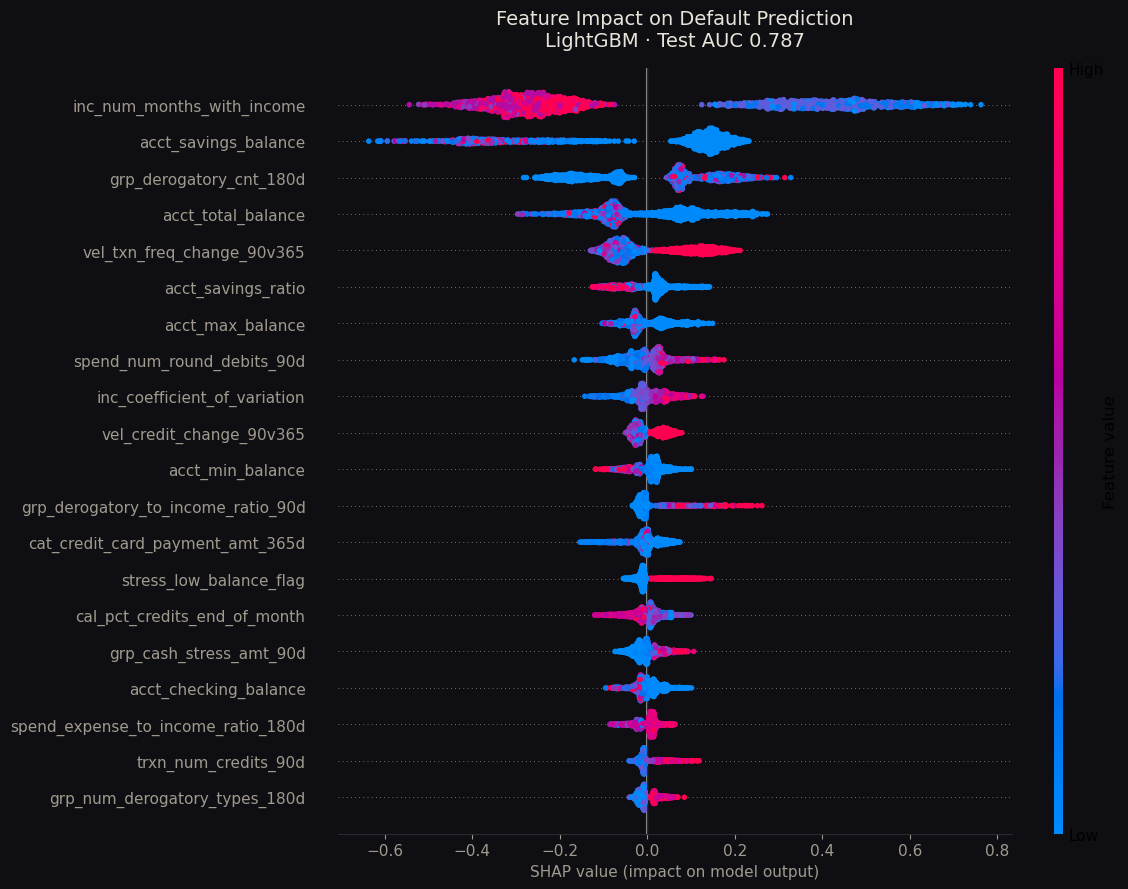

Saved: shap_beeswarm.png


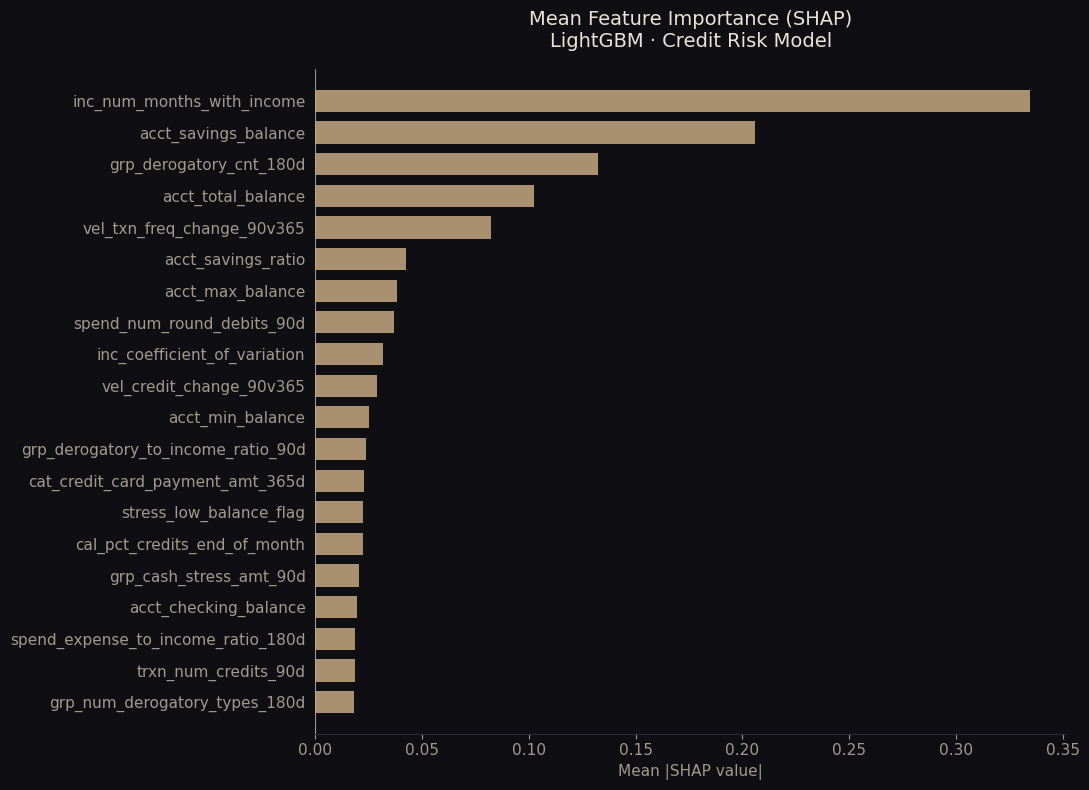

Saved: shap_bar.png

Top feature by mean |SHAP|: inc_num_months_with_income


<Figure size 1000x600 with 0 Axes>

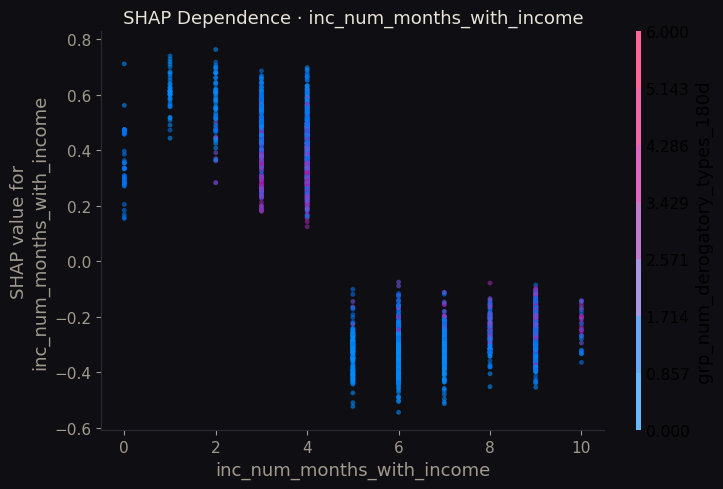

Saved: shap_dependence.png

Top 10 features by mean |SHAP value|:
inc_num_months_with_income      0.3349
acct_savings_balance            0.2060
grp_derogatory_cnt_180d         0.1326
acct_total_balance              0.1024
vel_txn_freq_change_90v365      0.0825
acct_savings_ratio              0.0423
acct_max_balance                0.0381
spend_num_round_debits_90d      0.0369
inc_coefficient_of_variation    0.0316
vel_credit_change_90v365        0.0289


In [79]:
import shap
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np

# ── 1. Compute SHAP values ───────────────────────────────────────────────────
explainer   = shap.TreeExplainer(best_lgbm)
shap_values = explainer.shap_values(X_test)

# For binary classification LightGBM returns a single array
# but some versions return a list — handle both
if isinstance(shap_values, list):
    sv = shap_values[1]   # positive class
else:
    sv = shap_values

# ── 2. Beeswarm summary plot (classic SHAP chart) ────────────────────────────
plt.figure(figsize=(12, 9))
shap.summary_plot(
    sv,
    X_test,
    max_display=20,
    show=False,
    plot_size=None,
    color_bar_label="Feature value",
)

ax = plt.gca()
ax.set_facecolor("#0f0f13")
plt.gcf().set_facecolor("#0f0f13")
ax.tick_params(colors="#a09a8e", labelsize=11)
ax.xaxis.label.set_color("#a09a8e")
for spine in ax.spines.values():
    spine.set_edgecolor("#2a2a35")
ax.axvline(0, color="#2a2a35", linewidth=1)
ax.set_xlabel("SHAP value (impact on model output)", color="#a09a8e", fontsize=11)
ax.set_title(
    "Feature Impact on Default Prediction\nLightGBM · Test AUC 0.787",
    color="#e8e4d9", fontsize=14, fontweight="normal", pad=16
)

plt.tight_layout()
plt.savefig("shap_beeswarm.png", dpi=150, bbox_inches="tight",
            facecolor="#0f0f13")
plt.show()
print("Saved: shap_beeswarm.png")

# ── 3. Bar plot — mean absolute SHAP (cleaner for presentations) ─────────────
plt.figure(figsize=(11, 8))
shap.summary_plot(
    sv,
    X_test,
    plot_type="bar",
    max_display=20,
    show=False,
    plot_size=None,
)

ax = plt.gca()
ax.set_facecolor("#0f0f13")
plt.gcf().set_facecolor("#0f0f13")
ax.tick_params(colors="#a09a8e", labelsize=11)
for spine in ax.spines.values():
    spine.set_edgecolor("#2a2a35")
for bar in ax.patches:
    bar.set_facecolor("#c4a882")
    bar.set_alpha(0.85)
ax.set_xlabel("Mean |SHAP value|", color="#a09a8e", fontsize=11)
ax.set_title(
    "Mean Feature Importance (SHAP)\nLightGBM · Credit Risk Model",
    color="#e8e4d9", fontsize=14, fontweight="normal", pad=16
)

plt.tight_layout()
plt.savefig("shap_bar.png", dpi=150, bbox_inches="tight",
            facecolor="#0f0f13")
plt.show()
print("Saved: shap_bar.png")

# ── 4. Dependence plot for top feature ───────────────────────────────────────
top_feature = X_test.columns[np.abs(sv).mean(axis=0).argmax()]
print(f"\nTop feature by mean |SHAP|: {top_feature}")

plt.figure(figsize=(10, 6))
shap.dependence_plot(
    top_feature,
    sv,
    X_test,
    show=False,
    dot_size=12,
    alpha=0.6,
)
ax = plt.gca()
ax.set_facecolor("#0f0f13")
plt.gcf().set_facecolor("#0f0f13")
ax.tick_params(colors="#a09a8e")
ax.xaxis.label.set_color("#a09a8e")
ax.yaxis.label.set_color("#a09a8e")
ax.set_title(f"SHAP Dependence · {top_feature}",
             color="#e8e4d9", fontsize=13, fontweight="normal")
for spine in ax.spines.values():
    spine.set_edgecolor("#2a2a35")

plt.tight_layout()
plt.savefig("shap_dependence.png", dpi=150, bbox_inches="tight",
            facecolor="#0f0f13")
plt.show()
print("Saved: shap_dependence.png")

# ── 5. Print top 10 features by mean |SHAP| ──────────────────────────────────
mean_shap = pd.Series(np.abs(sv).mean(axis=0), index=X_test.columns)
print("\nTop 10 features by mean |SHAP value|:")
print(mean_shap.nlargest(10).round(4).to_string())

In [41]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import RobustScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score
import numpy as np

pipe = Pipeline([
    ("scaler", RobustScaler()),
    ("clf", LogisticRegression(
        class_weight="balanced",
        max_iter=2000,
        C=0.1,
        solver="saga"
    ))
])

pipe.fit(X_train, y_train)
y_pred = pipe.predict_proba(X_test)[:, 1]
print("AUC:", roc_auc_score(y_test, y_pred))

# Check if any features are causing issues
print("\nFeatures with zero variance:", (X_train.std() == 0).sum())
print("Features with any NaN:", X_train.isna().any().sum())
print("Features with any Inf:", np.isinf(X_train).any().sum())

AUC: 0.5668836767284876

Features with zero variance: 6
Features with any NaN: 0
Features with any Inf: 0


/opt/conda/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


In [42]:
print(y_train.value_counts(normalize=True))
print(y_test.value_counts(normalize=True))

# 2. Check evaluation dates — are they consistent per consumer?
print(trxnDF.groupby("prism_consumer_id")["evaluation_date"].nunique().describe())

# 3. Check if any transactions are AFTER evaluation date
trxnDF["days_before_eval"] = (trxnDF["evaluation_date"] - trxnDF["posted_date"]).dt.days
print("Transactions after evaluation date:", (trxnDF["days_before_eval"] < 0).sum())
print("Transactions sample:")
print(trxnDF[["posted_date", "evaluation_date", "days_before_eval"]].describe())

# 4. Check feature correlations with target
correlations = X_train.corrwith(y_train).abs().sort_values(ascending=False)
print("\nTop 20 feature correlations with target:")
print(correlations.head(20))
print("\nBottom 10 feature correlations with target:")
print(correlations.tail(10))

# 5. Check for constant or near-constant features
low_var = X_train.std().sort_values().head(20)
print("\nLowest variance features:")
print(low_var)

DQ_TARGET
0    0.913476
1    0.086524
Name: proportion, dtype: float64
DQ_TARGET
0    0.912389
1    0.087611
Name: proportion, dtype: float64
count    10987.0
mean         1.0
std          0.0
min          1.0
25%          1.0
50%          1.0
75%          1.0
max          1.0
Name: evaluation_date, dtype: float64
Transactions after evaluation date: 0
Transactions sample:
                         posted_date                evaluation_date  \
count                        4906637                        4906637   
mean   2022-02-03 10:47:51.994159616  2022-05-08 04:20:49.858100736   
min              2020-07-06 00:00:00            2021-01-01 00:00:00   
25%              2021-07-28 00:00:00            2021-12-23 00:00:00   
50%              2021-10-29 00:00:00            2022-02-08 00:00:00   
75%              2022-03-05 00:00:00            2022-04-01 00:00:00   
max              2023-12-18 00:00:00            2023-12-18 00:00:00   
std                              NaN                     

/home/chc099/.local/lib/python3.11/site-packages/numpy/lib/function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/chc099/.local/lib/python3.11/site-packages/numpy/lib/function_base.py:2898: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


In [43]:
bad_cols = [
    "cat_small_dollar_advance_amt_90d",
    "cat_small_dollar_advance_cnt_90d", 
    "grp_has_payday_30d",
    "grp_has_payday_90d",
    "cat_paycheck_placeholder_cnt_90d",
    "cat_paycheck_placeholder_amt_90d",
]
X_train = X_train.drop(columns=bad_cols)
X_test  = X_test.drop(columns=bad_cols)

# 2. Check actual window coverage for your data
trxnDF["days_before_eval"] = (trxnDF["evaluation_date"] - trxnDF["posted_date"]).dt.days
for w in [30, 60, 90, 180, 365]:
    pct = (trxnDF["days_before_eval"] <= w).mean()
    print(f"Transactions within {w}d of eval: {pct:.1%}")

Transactions within 30d of eval: 20.1%
Transactions within 60d of eval: 39.1%
Transactions within 90d of eval: 57.1%
Transactions within 180d of eval: 85.9%
Transactions within 365d of eval: 100.0%
